Analiza podziału pędu wzdłużnego z wykorzyst. współczędnych Jacobi'ego Helmert'a

Z README struktura danych: 
p1x,p1y,p1z,
p2x,p2y,p2z,
p3x,p3y,p3z,
p4x,p4y,p4z.


gdzie:
- particle 1 = core;
- particle 2 = initially bound electron;
- particle 3 = initially bound electron;
- particle 4 = initially tunnelling electron.

bierzemy podział pędu wzdłużnego (wzdłuż z-ta):
p_2=p_{2z},\quad p_3=p_{3z},\quad p_4=p_{4z}.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

FILES = {
    #1.0: {
    #    "direct": r"ECBB_model\1.0PW_cm^2\momenta_direct_events.txt",
    #    "delayed": r"ECBB_model\1.0PW_cm^2\momenta_delayed_events.txt",
    #    "all": r"ECBB_model\1.0PW_cm^2\momenta_all_events.txt",
    #},
    #1.3: {
    #    "direct": r"ECBB_model\1.3PW_cm^2\momenta_direct_events.txt",
    #    "delayed": r"ECBB_model\1.3PW_cm^2\momenta_delayed_events.txt",
    #    "all": r"ECBB_model\1.3PW_cm^2\momenta_all_events.txt",
    #},
    #1.6: {
    #    "direct": r"ECBB_model\1.6PW_cm^2\momenta_direct_events.txt",
    #    "delayed": r"ECBB_model\1.6PW_cm^2\momenta_delayed_events.txt",
    #    "all": r"ECBB_model\1.6PW_cm^2\momenta_all_events.txt",
    #},
    1.7: {
        "direct": r"ECBB_model\data\data_Neon\ECBB_model\1.7PW_cm^2\momenta_direct_events.txt",
        "delayed": r"ECBB_model\data\data_Neon\ECBB_model\1.7PW_cm^2\momenta_delayed_events.txt",
        # "all": r"ECBB_model\data\data_Neon\ECBB_model\1.7PW_cm^2\momenta_all_events.txt",
    },
}

DATASETS = []

for intensity, pathways in FILES.items():
    for pathway, path in pathways.items():
        if path is None or str(path).strip() == "":
            continue

        DATASETS.append({
            "label": f"I={float(intensity):g} {pathway}",
            "intensity": float(intensity),
            "pathway": pathway,
            "path": str(path),
        })

if not DATASETS:
    raise ValueError("В FILES не указан ни один путь к данным.")

OUTPUT_DIR = Path("momentum_sharing_results")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

DPI = 170
BINS_1D = 80
BINS_2D = 120

print("Datasets configured:")
display(pd.DataFrame(DATASETS))
print(f"Results directory: {OUTPUT_DIR.resolve()}")

Datasets configured:


,label,intensity,pathway,path
0,I=1.7 direct,1.7,direct,ECBB_model\data\data_Neon\ECBB_model\1.7PW_cm^...
1,I=1.7 delayed,1.7,delayed,ECBB_model\data\data_Neon\ECBB_model\1.7PW_cm^...


Results directory: C:\Users\koran\Documents\UJ\Semestr 4\praktyka\momentum_sharing_results


każde zdarzenie:

$
\mathbf{p} =
\begin{pmatrix}
p_2 \\
p_3 \\
p_4
\end{pmatrix}.
$

baza ortonormalna (z PCA kierunków PC1 PC8 oraz PC9,  gdzie były tylko z):

- $
\mathbf{e}_0 =
\frac{1}{\sqrt{3}}
\begin{pmatrix}
1 \\
1 \\
1
\end{pmatrix},
$

- $
\mathbf{e}_1 =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 \\
-1 \\
0
\end{pmatrix},
$

- $
\mathbf{e}_2 =
\frac{1}{\sqrt{6}}
\begin{pmatrix}
1 \\
1 \\
-2
\end{pmatrix}.
$

czyli nowe współrzędne to będą:
- $
Q =
\frac{p_2+p_3+p_4}{\sqrt{3}},
$

- $
\xi_1 =
\frac{p_2-p_3}{\sqrt{2}},
$

- $
\xi_2 =
\frac{p_2+p_3-2p_4}{\sqrt{6}}.
$

gdzie

- $Q$ — ogólny podłużny tryb impulsowy elektronów.
- $\xi_1$ — asymetria między pierwotnie związanymi elektronami 2 и 3.
- $\xi_2$ — różnica między parą pierwotnie związanych elektronów a elektronem tunelowym 4.
- 
  $
  K=\sqrt{\xi_1^2+\xi_2^2}
  $
  — wartość względnej asymetrii impulsowej.

In [28]:
COLUMN_NAMES = [
    "p1x", "p1y", "p1z",
    "p2x", "p2y", "p2z",
    "p3x", "p3y", "p3z",
    "p4x", "p4y", "p4z",
]

def read_momentum_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    df = pd.read_csv(
        path,
        header=None,
        sep=r"[\s,]+",
        engine="python",
        comment="#",
    )
    df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")

    if df.shape[1] != 12:
        raise ValueError(f"Expected 12 columns, got {df.shape[1]} in {path}")

    df.columns = COLUMN_NAMES
    return df.astype(float)

def sign_label(values):
    labels = []
    for row in np.asarray(values):
        s = ""
        for v in row:
            if v > 0:
                s += "+"
            elif v < 0:
                s += "-"
            else:
                s += "0"
        labels.append(s)
    return labels

def process_dataset(df, label, intensity, pathway):
    out = df.copy()
    out["dataset"] = label
    out["intensity"] = intensity
    out["pathway"] = pathway

    p2 = out["p2z"].to_numpy()
    p3 = out["p3z"].to_numpy()
    p4 = out["p4z"].to_numpy()

    # Total electron longitudinal momentum
    out["P_e"] = p2 + p3 + p4
    out["Q"] = out["P_e"] / np.sqrt(3)

    # Jacobi/Helmert relative coordinates
    out["xi1_bound_bound"] = (p2 - p3) / np.sqrt(2)
    out["xi2_boundpair_tunnel"] = (p2 + p3 - 2*p4) / np.sqrt(6)
    out["K_relative"] = np.sqrt(out["xi1_bound_bound"]**2 + out["xi2_boundpair_tunnel"]**2)
    out["phi"] = np.arctan2(out["xi2_boundpair_tunnel"], out["xi1_bound_bound"])
    out["phi_deg"] = np.degrees(out["phi"])

    # Relative deviations from event-wise electron mean
    mean_p = out["P_e"] / 3.0
    out["q2"] = out["p2z"] - mean_p
    out["q3"] = out["p3z"] - mean_p
    out["q4"] = out["p4z"] - mean_p
    out["q_sum_check"] = out["q2"] + out["q3"] + out["q4"]

    # Momentum conservation/recoil check with core
    out["P_total_with_core_z"] = out["p1z"] + out["p2z"] + out["p3z"] + out["p4z"]

    # Orthonormal transform check
    out["norm_original_z"] = out["p2z"]**2 + out["p3z"]**2 + out["p4z"]**2
    out["norm_jacobi_z"] = out["Q"]**2 + out["xi1_bound_bound"]**2 + out["xi2_boundpair_tunnel"]**2
    out["norm_transform_error"] = out["norm_original_z"] - out["norm_jacobi_z"]

    # Signed-simplex / momentum fractions
    A = np.abs(p2) + np.abs(p3) + np.abs(p4)
    A_safe = np.where(A == 0, np.nan, A)
    out["A_l1"] = A
    out["x2_abs_share"] = np.abs(p2) / A_safe
    out["x3_abs_share"] = np.abs(p3) / A_safe
    out["x4_abs_share"] = np.abs(p4) / A_safe
    x = out[["x2_abs_share", "x3_abs_share", "x4_abs_share"]].to_numpy()

    out["x_sum_check"] = np.nansum(x, axis=1)
    out["x_max"] = np.nanmax(x, axis=1)
    out["N_eff_abs_share"] = 1.0 / np.nansum(x**2, axis=1)

    eps = 1e-15
    x_safe = np.clip(x, eps, 1.0)
    out["entropy_abs_share"] = -np.sum(x_safe*np.log(x_safe), axis=1) / np.log(3)

    out["sign_sector"] = sign_label(out[["p2z", "p3z", "p4z"]].to_numpy())

    # ilr log-ratio coordinates for absolute shares
    eps_lr = 1e-12
    x2 = np.clip(out["x2_abs_share"].to_numpy(), eps_lr, None)
    x3 = np.clip(out["x3_abs_share"].to_numpy(), eps_lr, None)
    x4 = np.clip(out["x4_abs_share"].to_numpy(), eps_lr, None)
    s = x2 + x3 + x4
    x2, x3, x4 = x2/s, x3/s, x4/s
    out["ilr1_x2_vs_x3"] = (1/np.sqrt(2)) * np.log(x2/x3)
    out["ilr2_boundpair_vs_x4"] = (1/np.sqrt(6)) * np.log((x2*x3)/(x4**2))

    # Pairwise differences/correlations
    out["d23"] = out["p2z"] - out["p3z"]
    out["d24"] = out["p2z"] - out["p4z"]
    out["d34"] = out["p3z"] - out["p4z"]

    return out

odczytuj pliki i utwórz tabelę `combined` zawierającą wszystkie nowe zmienne.

In [29]:
processed = []

for spec in DATASETS:
    raw = read_momentum_file(spec["path"])
    tmp = process_dataset(
        raw,
        label=spec["label"],
        intensity=spec.get("intensity", np.nan),
        pathway=spec.get("pathway", "unknown"),
    )
    processed.append(tmp)

combined = pd.concat(processed, ignore_index=True)

print("Loaded rows by dataset:")
display(combined.groupby(["dataset", "intensity", "pathway"]).size().rename("n_events").reset_index())

print("\nFirst rows with original longitudinal momenta and new variables:")
display(combined[[
    "dataset", "p1z", "p2z", "p3z", "p4z",
    "P_e", "Q", "xi1_bound_bound", "xi2_boundpair_tunnel",
    "K_relative", "x2_abs_share", "x3_abs_share", "x4_abs_share",
    "N_eff_abs_share", "x_max", "sign_sector"
]].head(10))

Loaded rows by dataset:


,dataset,intensity,pathway,n_events
0,I=1.7 delayed,1.7,delayed,1601
1,I=1.7 direct,1.7,direct,1695



First rows with original longitudinal momenta and new variables:


,dataset,p1z,p2z,p3z,p4z,P_e,Q,xi1_bound_bound,xi2_boundpair_tunnel,K_relative,x2_abs_share,x3_abs_share,x4_abs_share,N_eff_abs_share,x_max,sign_sector
0,I=1.7 direct,6.100505,-3.292359,-1.971315,-1.224288,-6.487961,-3.745826,-0.934119,-1.149259,1.481005,0.507457,0.303842,0.188701,2.594435,0.507457,---
1,I=1.7 direct,-8.165295,3.926861,2.883397,2.147512,8.957770,5.171771,0.737840,1.026840,1.264440,0.438375,0.321888,0.239737,2.830790,0.438375,+++
2,I=1.7 direct,-8.932233,1.519567,1.858649,3.558018,6.936233,4.004636,-0.239767,-1.525959,1.544681,0.219077,0.267962,0.512961,2.611461,0.512961,+++
3,I=1.7 direct,1.319968,-1.116379,1.236401,-2.939693,-2.819671,-1.627938,-1.663667,2.449248,2.960845,0.210937,0.233615,0.555448,2.453429,0.555448,-+-
4,I=1.7 direct,3.775452,0.308961,-2.159729,-2.684345,-4.535113,-2.618349,1.745627,1.436185,2.260496,0.059957,0.419118,0.520925,2.219177,0.520925,+--
5,I=1.7 direct,8.626768,-2.920368,-2.731318,-2.628343,-8.280029,-4.780477,-0.133678,-0.161258,0.209462,0.352700,0.329868,0.317432,2.994251,0.352700,---
6,I=1.7 direct,-11.142322,2.403629,2.342949,2.907450,7.654028,4.419055,0.042907,-0.436141,0.438247,0.314034,0.306107,0.379859,2.970782,0.379859,+++
7,I=1.7 direct,-4.527835,2.274363,2.169678,1.341347,5.785388,3.340195,0.074023,0.719067,0.722867,0.393122,0.375027,0.231851,2.865780,0.393122,+++
8,I=1.7 direct,-4.848504,2.784338,2.256894,1.251489,6.292720,3.633104,0.372959,1.036238,1.101312,0.442470,0.358652,0.198879,2.747531,0.442470,+++
9,I=1.7 direct,-7.133918,2.446606,1.586265,3.494877,7.527748,4.346147,0.608353,-1.207142,1.351771,0.325012,0.210722,0.464266,2.735384,0.464266,+++


główne observables to
- $P_e=p_2+p_3+p_4$: total electron longitudinal momentum.
- $K$: magnitude of relative sharing imbalance.
- $N_\mathrm{eff}$: effective number of electrons participating in absolute longitudinal momentum sharing.
- $x_{max}$: largest single-electron share.
- sign sector: forward/backward emission pattern.

In [30]:
def third_centered_cumulant(g):
    q2 = g["p2z"] - g["p2z"].mean()
    q3 = g["p3z"] - g["p3z"].mean()
    q4 = g["p4z"] - g["p4z"].mean()
    return float(np.mean(q2*q3*q4))

def build_summary_table(df):
    rows = []
    for (intensity, pathway, label), g in df.groupby(["intensity", "pathway", "dataset"], dropna=False):
        sectors = g["sign_sector"].value_counts(normalize=True)
        dominant_sector = sectors.index[0]
        rows.append({
            "dataset": label,
            "intensity": intensity,
            "pathway": pathway,
            "n_events": len(g),
            "mean_P_e": g["P_e"].mean(),
            "std_P_e": g["P_e"].std(),
            "mean_K_relative": g["K_relative"].mean(),
            "std_K_relative": g["K_relative"].std(),
            "mean_N_eff_abs_share": g["N_eff_abs_share"].mean(),
            "median_N_eff_abs_share": g["N_eff_abs_share"].median(),
            "mean_x_max": g["x_max"].mean(),
            "median_x_max": g["x_max"].median(),
            "mean_entropy_abs_share": g["entropy_abs_share"].mean(),
            "dominant_sign_sector": dominant_sector,
            "dominant_sign_sector_fraction": sectors.iloc[0],
            "corr_p2_p3": g[["p2z", "p3z"]].corr().iloc[0,1],
            "corr_p2_p4": g[["p2z", "p4z"]].corr().iloc[0,1],
            "corr_p3_p4": g[["p3z", "p4z"]].corr().iloc[0,1],
            "kappa234_centered": third_centered_cumulant(g),
        })
    return pd.DataFrame(rows)

summary = build_summary_table(combined)
display(summary)
summary.to_csv(OUTPUT_DIR / "summary_table.csv", index=False)

,dataset,intensity,pathway,n_events,mean_P_e,std_P_e,mean_K_relative,std_K_relative,mean_N_eff_abs_share,median_N_eff_abs_share,mean_x_max,median_x_max,mean_entropy_abs_share,dominant_sign_sector,dominant_sign_sector_fraction,corr_p2_p3,corr_p2_p4,corr_p3_p4,kappa234_centered
0,I=1.7 delayed,1.7,delayed,1601,0.146523,5.384157,2.382969,1.138893,2.373879,2.385681,0.533299,0.517548,0.846384,+++,0.230481,0.213718,0.456153,0.437087,0.122988
1,I=1.7 direct,1.7,direct,1695,0.319874,7.543179,1.397943,0.665472,2.628165,2.725829,0.473086,0.455860,0.919058,+++,0.474336,0.868137,0.812940,0.813748,-0.997347


# Wykresy
- histogram podziału pędu między elektronami:
- x: między związanymi
- y: związanych z  tunelowanym

DATASET: I=1.7 delayed, n=1601


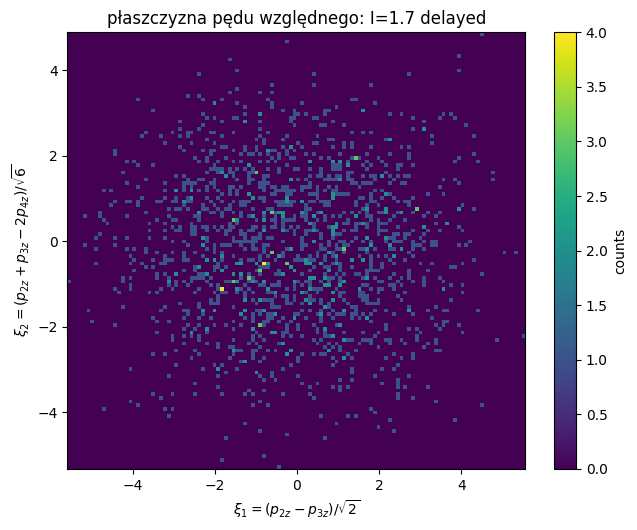

Saved: momentum_sharing_results\I=1.7_delayed__jacobi_density.png
DATASET: I=1.7 direct, n=1695


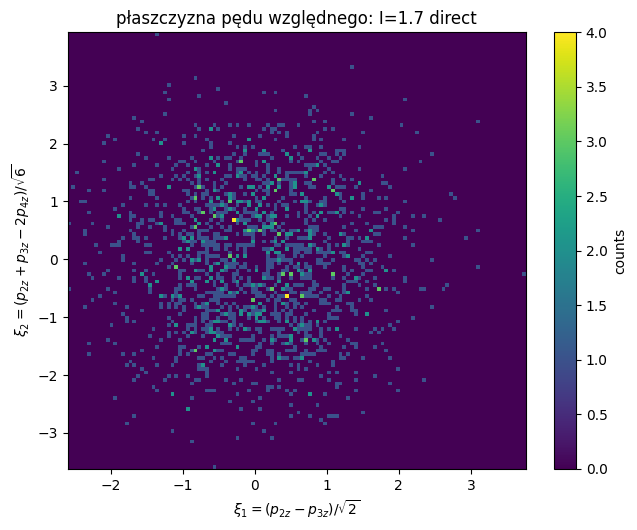

Saved: momentum_sharing_results\I=1.7_direct__jacobi_density.png


In [31]:
def save_current_fig(name):
    path = OUTPUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=DPI, bbox_inches="tight")
    return path

def plot_jacobi_density(g, label):
    plt.figure(figsize=(6.6, 5.4))
    plt.hist2d(g["xi1_bound_bound"], g["xi2_boundpair_tunnel"], bins=BINS_2D)
    plt.xlabel(r"$\xi_1=(p_{2z}-p_{3z})/\sqrt{2}$")
    plt.ylabel(r"$\xi_2=(p_{2z}+p_{3z}-2p_{4z})/\sqrt{6}$")
    plt.title(f"płaszczyzna pędu względnego: {label}")
    plt.colorbar(label="counts")
    path = save_current_fig(f"{label.replace(' ', '_')}__jacobi_density.png")
    plt.show()
    print(f"Saved: {path}")

for label, g in combined.groupby("dataset"):
    print("="*90)
    print(f"DATASET: {label}, n={len(g)}")
    plot_jacobi_density(g, label)

- porównanie całkowitego pędu z miarą nierównowagi (pierwiastek z sumy kwadratów poprzednich współrzędnych)

DATASET: I=1.7 delayed, n=1601


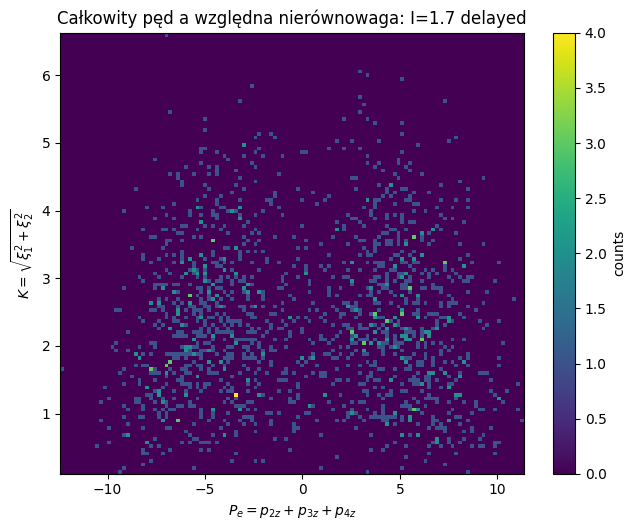

Saved: momentum_sharing_results\I=1.7_delayed__P_vs_K.png
DATASET: I=1.7 direct, n=1695


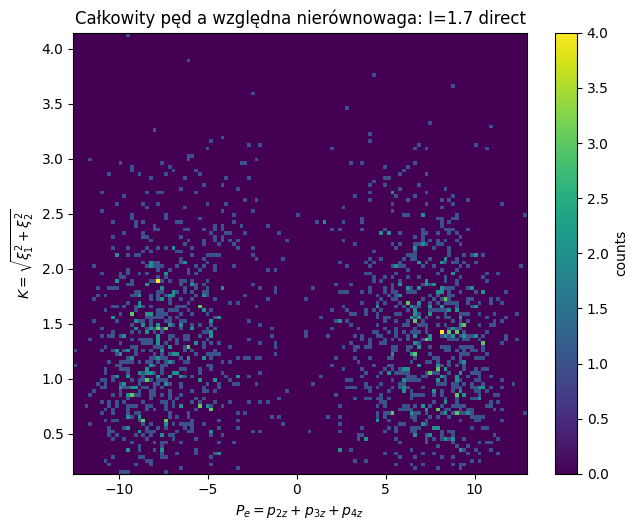

Saved: momentum_sharing_results\I=1.7_direct__P_vs_K.png


In [32]:
def plot_P_vs_K(g, label):
    plt.figure(figsize=(6.6, 5.4))
    plt.hist2d(g["P_e"], g["K_relative"], bins=BINS_2D)
    plt.xlabel(r"$P_e=p_{2z}+p_{3z}+p_{4z}$")
    plt.ylabel(r"$K=\sqrt{\xi_1^2+\xi_2^2}$")
    plt.title(f"Całkowity pęd a względna nierównowaga: {label}")
    plt.colorbar(label="counts")
    path = save_current_fig(f"{label.replace(' ', '_')}__P_vs_K.png")
    plt.show()
    print(f"Saved: {path}")

for label, g in combined.groupby("dataset"):
    print("="*90)
    print(f"DATASET: {label}, n={len(g)}")
    plot_P_vs_K(g, label)

- histogram równomierności podziału danych 

DATASET: I=1.7 delayed, n=1601


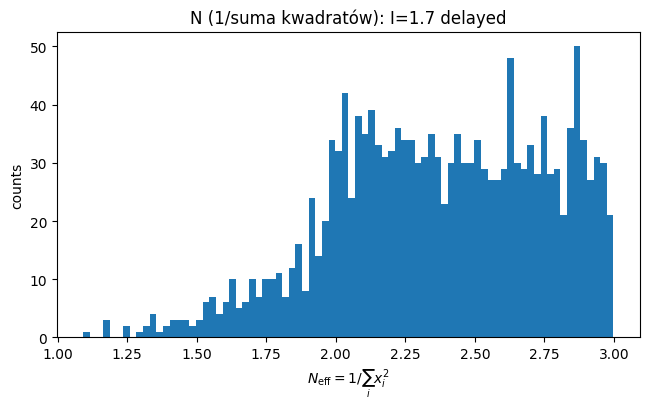

Saved: momentum_sharing_results\I=1.7_delayed__Neff_hist.png
DATASET: I=1.7 direct, n=1695


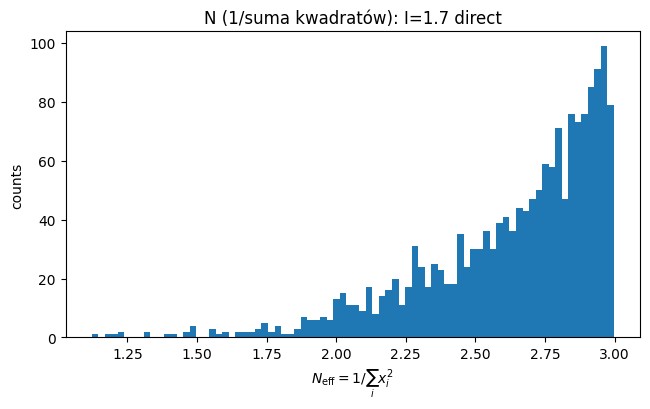

Saved: momentum_sharing_results\I=1.7_direct__Neff_hist.png


In [33]:
def plot_simplex_summaries(g, label):
    plt.figure(figsize=(6.6, 4.2))
    plt.hist(g["N_eff_abs_share"], bins=BINS_1D)
    plt.xlabel(r"$N_{\mathrm{eff}}=1/\sum_i x_i^2$")
    plt.ylabel("counts")
    plt.title(f"N (1/suma kwadratów): {label}")
    path = save_current_fig(f"{label.replace(' ', '_')}__Neff_hist.png")
    plt.show()
    print(f"Saved: {path}")

for label, g in combined.groupby("dataset"):
    print("="*90)
    print(f"DATASET: {label}, n={len(g)}")
    plot_simplex_summaries(g, label)

- w którą stronę lecą elektrony

DATASET: I=1.7 delayed, n=1601


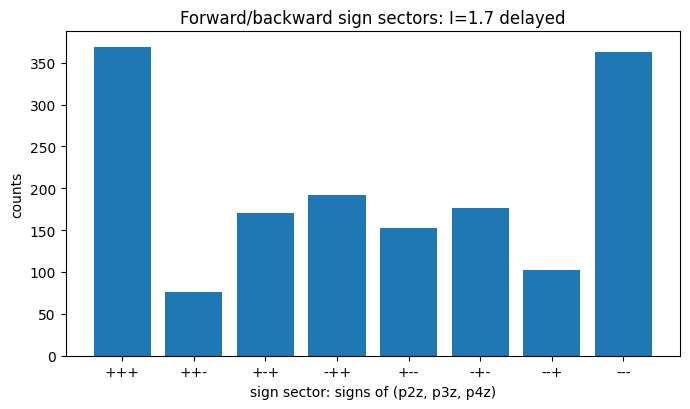

Saved: momentum_sharing_results\I=1.7_delayed__sign_sectors.png
DATASET: I=1.7 direct, n=1695


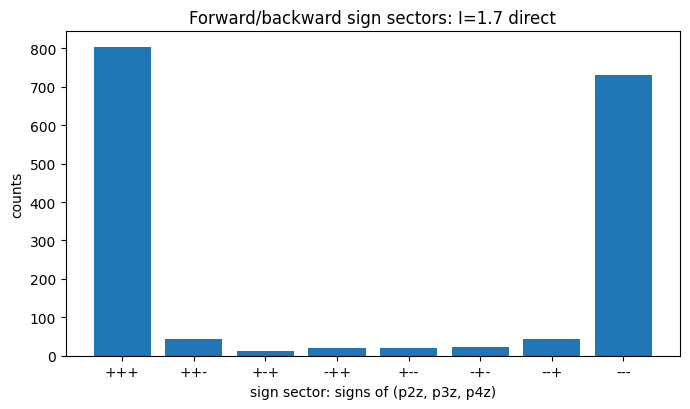

Saved: momentum_sharing_results\I=1.7_direct__sign_sectors.png


In [34]:

def plot_sign_sectors(g, label):
    counts = g["sign_sector"].value_counts()
    order = ["+++", "++-", "+-+", "-++", "+--", "-+-", "--+", "---"]
    order = [s for s in order if s in counts.index] + [s for s in counts.index if s not in order]
    counts = counts.reindex(order)

    plt.figure(figsize=(7.0, 4.2))
    plt.bar(counts.index, counts.values)
    plt.xlabel("sign sector: signs of (p2z, p3z, p4z)")
    plt.ylabel("counts")
    plt.title(f"Forward/backward sign sectors: {label}")
    path = save_current_fig(f"{label.replace(' ', '_')}__sign_sectors.png")
    plt.show()
    print(f"Saved: {path}")

for label, g in combined.groupby("dataset"):
    print("="*90)
    print(f"DATASET: {label}, n={len(g)}")
    plot_sign_sectors(g, label)

DATASET: I=1.7 delayed, n=1601


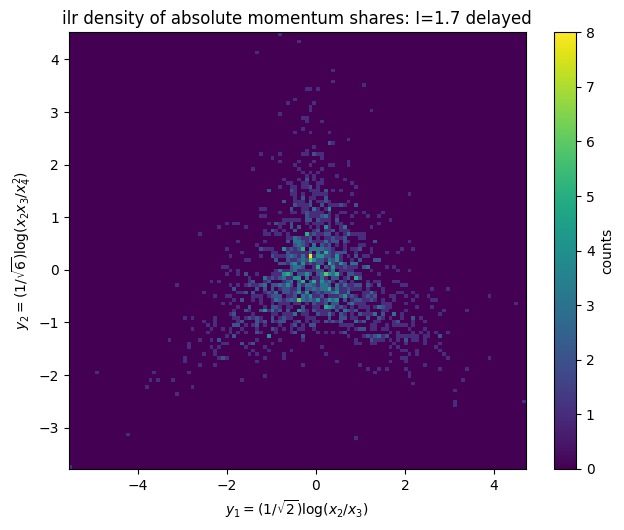

Saved: momentum_sharing_results\I=1.7_delayed__ilr_density.png
DATASET: I=1.7 direct, n=1695


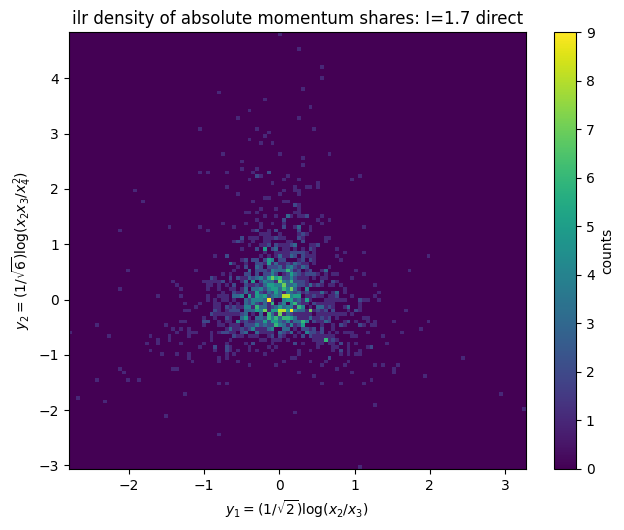

Saved: momentum_sharing_results\I=1.7_direct__ilr_density.png


In [35]:
def plot_ilr_density(g, label):
    plt.figure(figsize=(6.6, 5.4))
    plt.hist2d(g["ilr1_x2_vs_x3"], g["ilr2_boundpair_vs_x4"], bins=BINS_2D)
    plt.xlabel(r"$y_1=(1/\sqrt{2})\log(x_2/x_3)$")
    plt.ylabel(r"$y_2=(1/\sqrt{6})\log(x_2x_3/x_4^2)$")
    plt.title(f"ilr density of absolute momentum shares: {label}")
    plt.colorbar(label="counts")
    path = save_current_fig(f"{label.replace(' ', '_')}__ilr_density.png")
    plt.show()
    print(f"Saved: {path}")

for label, g in combined.groupby("dataset"):
    print("="*90)
    print(f"DATASET: {label}, n={len(g)}")
    plot_ilr_density(g, label)

DATASET: I=1.7 delayed, n=1601


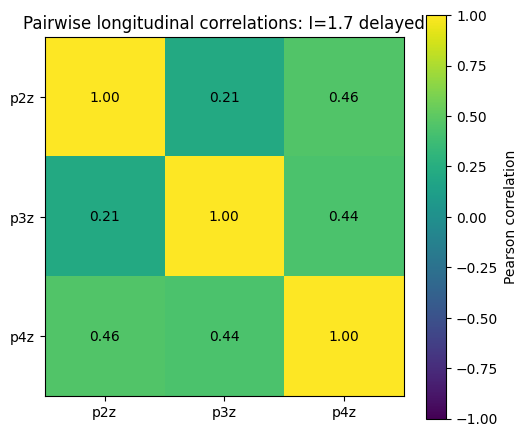

Saved: momentum_sharing_results\I=1.7_delayed__pairwise_corr.png
DATASET: I=1.7 direct, n=1695


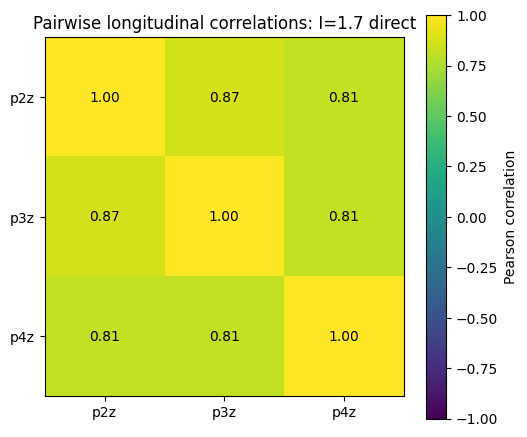

Saved: momentum_sharing_results\I=1.7_direct__pairwise_corr.png


In [36]:
def plot_pairwise_corr(g, label):
    corr = g[["p2z","p3z","p4z"]].corr()

    plt.figure(figsize=(5.4, 4.6))
    im = plt.imshow(corr.values, vmin=-1, vmax=1)
    plt.xticks(range(3), corr.columns)
    plt.yticks(range(3), corr.index)
    plt.colorbar(im, label="Pearson correlation")
    plt.title(f"Pairwise longitudinal correlations: {label}")
    for i in range(3):
        for j in range(3):
            plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")
    path = save_current_fig(f"{label.replace(' ', '_')}__pairwise_corr.png")
    plt.show()
    print(f"Saved: {path}")

for label, g in combined.groupby("dataset"):
    print("="*90)
    print(f"DATASET: {label}, n={len(g)}")
    plot_pairwise_corr(g, label)

In [37]:
def generate_talking_points(summary, sanity):
    lines = []

    lines.append("-------------------")
    lines.append("PCA would choose axes from the covariance of a particular dataset.")
    lines.append("Here the axes are fixed by few-body kinematics and by the physical labels of the electrons.")
    lines.append("Therefore direct/delayed pathways and different intensities can be compared in the same coordinate system.")
    lines.append("")
    lines.append("SIMPLEX GENERALIZATION")
    lines.append("----------------------")
    lines.append("The signed-simplex representation uses x_i=|p_iz|/sum_j|p_jz| and the signs of p_iz separately.")
    lines.append("For 3 electrons this is a triangle. For 4 electrons it becomes a tetrahedron. For N electrons it becomes an (N-1)-simplex.")
    lines.append("So the triangle is not abandoned; it is generalized.")
    lines.append("")
    lines.append("SANITY CHECKS")
    lines.append("-------------")
    for _, r in sanity.iterrows():
        lines.append(
            f"{r['dataset']}: max orthonormal transform error = {r['max_abs_norm_transform_error']:.3e}; "
            f"max |q2+q3+q4| = {r['max_abs_q_sum_check']:.3e}; "
            f"mean |core residual| = {r['mean_abs_core_residual']:.3e}."
        )
    lines.append("")
    lines.append("DATASET OBSERVATIONS")
    lines.append("--------------------")
    for _, r in summary.iterrows():
        lines.append(
            f"{r['dataset']}: n={int(r['n_events'])}, "
            f"mean K={r['mean_K_relative']:.3f}, "
            f"mean N_eff={r['mean_N_eff_abs_share']:.3f}, "
            f"mean x_max={r['mean_x_max']:.3f}, "
            f"dominant sign sector={r['dominant_sign_sector']} "
            f"({100*r['dominant_sign_sector_fraction']:.1f}%)."
        )
    return "\n".join(lines)

talking_points = generate_talking_points(summary, sanity)
print(talking_points)

with open(OUTPUT_DIR / "talking_points.txt", "w", encoding="utf-8") as f:
    f.write(talking_points)

-------------------
PCA would choose axes from the covariance of a particular dataset.
Here the axes are fixed by few-body kinematics and by the physical labels of the electrons.
Therefore direct/delayed pathways and different intensities can be compared in the same coordinate system.

SIMPLEX GENERALIZATION
----------------------
The signed-simplex representation uses x_i=|p_iz|/sum_j|p_jz| and the signs of p_iz separately.
For 3 electrons this is a triangle. For 4 electrons it becomes a tetrahedron. For N electrons it becomes an (N-1)-simplex.
So the triangle is not abandoned; it is generalized.

SANITY CHECKS
-------------
I=1.7 all: max orthonormal transform error = 2.132e-14; max |q2+q3+q4| = 1.776e-15; mean |core residual| = 1.275e+00.

DATASET OBSERVATIONS
--------------------
I=1.7 delayed: n=1601, mean K=2.383, mean N_eff=2.374, mean x_max=0.533, dominant sign sector=+++ (23.0%).
I=1.7 direct: n=1695, mean K=1.398, mean N_eff=2.628, mean x_max=0.473, dominant sign sector=+++ (

# 8. Direct vs delayed comparison

Когда ты добавишь реальные direct/delayed файлы, эта ячейка покажет разницу между pathways при одной intensity.

Что смотреть:

- `delta_mean_K_delayed_minus_direct`
  - если положительно: delayed имеет более asymmetric sharing.
- `delta_mean_Neff_delayed_minus_direct`
  - если отрицательно: delayed имеет меньший effective number of participating electrons.
- `dominant sign sector`
  - показывает forward/backward emission pattern.

In [38]:
def compare_direct_delayed(summary_table):
    rows = []
    for intensity, g in summary_table.groupby("intensity"):
        if not {"direct", "delayed"}.issubset(set(g["pathway"])):
            continue

        direct = g[g["pathway"] == "direct"].iloc[0]
        delayed = g[g["pathway"] == "delayed"].iloc[0]

        rows.append({
            "intensity": intensity,
            "delta_mean_K_delayed_minus_direct": delayed["mean_K_relative"] - direct["mean_K_relative"],
            "delta_mean_Neff_delayed_minus_direct": delayed["mean_N_eff_abs_share"] - direct["mean_N_eff_abs_share"],
            "delta_mean_xmax_delayed_minus_direct": delayed["mean_x_max"] - direct["mean_x_max"],
            "direct_dominant_sector": direct["dominant_sign_sector"],
            "delayed_dominant_sector": delayed["dominant_sign_sector"],
        })
    return pd.DataFrame(rows)

direct_delayed_comparison = compare_direct_delayed(summary)

if len(direct_delayed_comparison) == 0:
    print("No direct/delayed pairs found yet. Add real files with pathway='direct' and pathway='delayed', then Run All.")
else:
    display(direct_delayed_comparison)
    direct_delayed_comparison.to_csv(OUTPUT_DIR / "direct_delayed_comparison.csv", index=False)

,intensity,delta_mean_K_delayed_minus_direct,delta_mean_Neff_delayed_minus_direct,delta_mean_xmax_delayed_minus_direct,direct_dominant_sector,delayed_dominant_sector
0,1.7,0.985025,-0.254286,0.060214,+++,+++


# 9. Reconstruction check

Показываем, что Jacobi coordinates не теряют информацию.

\[
p_2=\frac{Q}{\sqrt{3}}+\frac{\xi_1}{\sqrt{2}}+\frac{\xi_2}{\sqrt{6}},
\]

\[
p_3=\frac{Q}{\sqrt{3}}-\frac{\xi_1}{\sqrt{2}}+\frac{\xi_2}{\sqrt{6}},
\]

\[
p_4=\frac{Q}{\sqrt{3}}-\frac{2\xi_2}{\sqrt{6}}.
\]

In [39]:
Q = combined["Q"]
xi1 = combined["xi1_bound_bound"]
xi2 = combined["xi2_boundpair_tunnel"]

p2_rec = Q/np.sqrt(3) + xi1/np.sqrt(2) + xi2/np.sqrt(6)
p3_rec = Q/np.sqrt(3) - xi1/np.sqrt(2) + xi2/np.sqrt(6)
p4_rec = Q/np.sqrt(3) - 2*xi2/np.sqrt(6)

reconstruction_errors = pd.DataFrame({
    "max_abs_p2_error": [np.max(np.abs(p2_rec - combined["p2z"]))],
    "max_abs_p3_error": [np.max(np.abs(p3_rec - combined["p3z"]))],
    "max_abs_p4_error": [np.max(np.abs(p4_rec - combined["p4z"]))],
})

display(reconstruction_errors)
reconstruction_errors.to_csv(OUTPUT_DIR / "reconstruction_errors.csv", index=False)

,max_abs_p2_error,max_abs_p3_error,max_abs_p4_error
0,1.776357e-15,1.554312e-15,1.776357e-15


# 10. Export processed data

Сохраняем таблицы, чтобы потом можно было использовать их отдельно.

In [40]:
processed_path = OUTPUT_DIR / "processed_momentum_sharing_data.csv"
combined.to_csv(processed_path, index=False)

print(f"Processed data saved to: {processed_path}")
print(f"Summary table saved to: {OUTPUT_DIR / 'summary_table.csv'}")
print(f"Sanity summary saved to: {OUTPUT_DIR / 'sanity_summary.csv'}")
print(f"Talking points saved to: {OUTPUT_DIR / 'talking_points.txt'}")
print(f"Figures saved to: {OUTPUT_DIR}")

Processed data saved to: momentum_sharing_results\processed_momentum_sharing_data.csv
Summary table saved to: momentum_sharing_results\summary_table.csv
Sanity summary saved to: momentum_sharing_results\sanity_summary.csv
Talking points saved to: momentum_sharing_results\talking_points.txt
Figures saved to: momentum_sharing_results
